# Assisted units in Pinellas housing records

The Pinellas County assisted-housing layer reports total units and assisted units for mapped housing records. This notebook asks how often both counts are usable and how their reported values compare. It treats each polygon row as a mapped record, because repeated site identifiers could otherwise double-count units.

Source: [Pinellas assisted-housing layer](https://services.arcgis.com/f5HgUpxURgEzTccH/ArcGIS/rest/services/Pinellas_AssistedHousing_view/FeatureServer/0). The package's checked catalog provides the publisher attribution and scope note.

## 1. Inspect the checked source

The numeric unit fields and source identifiers are verified against the bundled schema. Their values come from the live publisher service when the next cell runs.

In [1]:
library(tampaBayOpenData)

id <- "pinellas-assisted-housing"
fields <- c("PID", "DEVELOPMENT", "CITY", "HOUSINGPROGRAM",
            "TOTALUNITS", "ASSISTEDUNITS")
info <- tbod_dataset_info(id)
schema <- tbod_schema(id)
stopifnot(all(fields %in% schema$fields$name))
cat(info$publisher, "-", info$title, "\n")
cat("Source:", info$source_url, "\n")
cat("Scope:", info$scope_note, "\n")

Pinellas County - Pinellas assisted housing 


Source: https://pinellas-egis.maps.arcgis.com/home/item.html?id=2277d597855b4fba9e4c3e892bc5ddd7 


Scope: Program participation, assisted-unit counts, and subsidy expiration may change. This layer does not establish current eligibility, availability, or a complete affordable-housing inventory. 


## 2. Retrieve the full matching layer

The provenance check requires a complete result before interpreting its distribution. It still represents a live service rather than a frozen historical snapshot.

In [2]:
homes <- tbod_get_dataset(id, fields = fields, total_timeout = 180)
source <- tbod_provenance(homes)
stopifnot(isTRUE(source$complete),
          source$returned_rows == nrow(homes),
          source$matched_rows == nrow(homes))
cat(sprintf("%s mapped records retrieved at %s; integrity: %s\n",
            format(nrow(homes), big.mark = ","),
            format(source$retrieved_at, tz = "UTC", usetz = TRUE),
            source$integrity))

191 mapped records retrieved at 2026-10-06 22:39:06 UTC; integrity: full-manifest


## 3. Check the unit fields

A share is defined only when total units are positive and assisted units fall between zero and total units. Missing and inconsistent rows remain visible in the audit instead of silently disappearing.

In [3]:
total <- homes$TOTALUNITS
assisted <- homes$ASSISTEDUNITS
both <- is.finite(total) & is.finite(assisted)
valid <- both & total > 0 & assisted >= 0 & assisted <= total
pid <- trimws(as.character(homes$PID))
pid <- pid[!is.na(pid) & nzchar(pid)]
checks <- data.frame(
  measure = c("All mapped records", "Missing either unit count",
              "Zero total units with both counts", "Inconsistent unit counts",
              "Usable unit pairs", "Repeated nonblank PID values"),
  count = c(nrow(homes), sum(!both), sum(both & total == 0),
            sum(both & (total < 0 | assisted < 0 | assisted > total)),
            sum(valid), sum(duplicated(pid)))
)
print(checks, row.names = FALSE)
usable <- homes[valid, , drop = FALSE]
if (nrow(usable)) {
  share <- usable$ASSISTEDUNITS / usable$TOTALUNITS
  cat(sprintf("Median assisted share among usable mapped records: %.1f%%\n",
              100 * median(share)))
}

                           measure count
                All mapped records   191
         Missing either unit count    40
 Zero total units with both counts     0
          Inconsistent unit counts     0
                 Usable unit pairs   151
      Repeated nonblank PID values     7


Median assisted share among usable mapped records: 100.0%


## 4. Compare counts within each mapped record

The diagonal represents equal assisted and total units. Points below it report fewer assisted units than total units. No unit counts are summed across polygons, so repeated site identifiers cannot inflate a regional total here.

33 of 151 usable records report fewer assisted than total units.


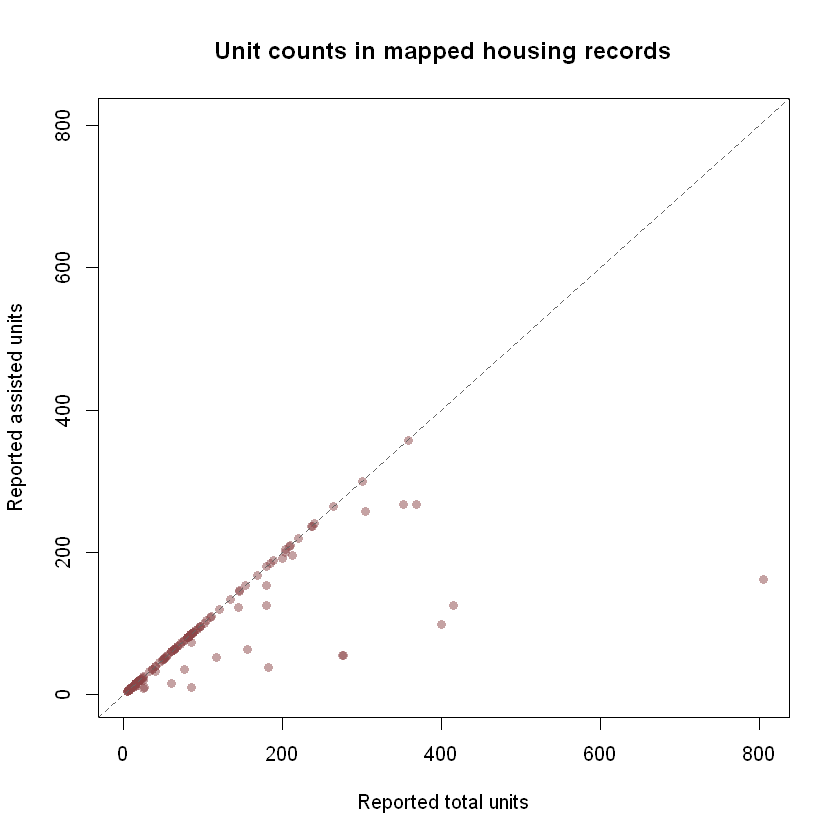

In [4]:
if (nrow(usable)) {
  upper <- max(c(usable$TOTALUNITS, usable$ASSISTEDUNITS))
  plot(usable$TOTALUNITS, usable$ASSISTEDUNITS,
       xlim = c(0, upper), ylim = c(0, upper),
       pch = 16, col = grDevices::rgb(0.55, 0.27, 0.28, 0.5),
       xlab = "Reported total units", ylab = "Reported assisted units",
       main = "Unit counts in mapped housing records")
  abline(0, 1, lty = 2, col = "gray40")
  cat(sprintf("%d of %d usable records report fewer assisted than total units.\n",
              sum(usable$ASSISTEDUNITS < usable$TOTALUNITS), nrow(usable)))
} else {
  plot.new()
  text(0.5, 0.5, "No records have usable unit pairs")
}

## What this shows

The analysis describes the publisher's mapped housing records, with each polygon row shown once. Program participation and unit counts can change. The layer does not establish current eligibility, vacancies, or a complete affordable-housing inventory. Repeated PIDs in the audit warrant site-level review before aggregating unit totals.